# License Plate Recognition

@misc{
license-plate-recognition-rxg4e_dataset,
title = { License Plate Recognition Dataset },
type = { Open Source Dataset },
author = { Roboflow Universe Projects },
howpublished = { \url{ https://universe.roboflow.com/roboflow-universe-projects/license-plate-recognition-rxg4e } },
url = { https://universe.roboflow.com/roboflow-universe-projects/license-plate-recognition-rxg4e },
journal = { Roboflow Universe },
publisher = { Roboflow },
year = { 2024 },
month = { oct },
note = { visited on 2025-02-17 },
}

* References
    1. https://github.com/tensorflow/models/blob/master/research/object_detection/colab_tutorials/eager_few_shot_od_training_tf2_colab.ipynb
    2. https://tensorflow-object-detection-api-tutorial.readthedocs.io/en/latest/training.html#evaluating-the-model-optional

## Imports

In [1]:
# Go to project root folder
import os
os.chdir("../")
%pwd

'/workspaces/license-plate-recognition'

In [2]:
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.random.set_seed(42)

In [3]:
found_gpu = tf.config.list_physical_devices('GPU')
# if not found_gpu:
#     raise Exception("No GPU found")
found_gpu, tf.__version__

([], '2.15.1')

In [4]:
# import the label map utility module
from object_detection.utils import label_map_util

# import module for reading and updating configuration files.
from object_detection.utils import config_util

# import module for visualization. use the alias `viz_utils`
from object_detection.utils import visualization_utils as viz_utils

# import module for building the detection model
from object_detection.builders import model_builder

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
load_dotenv()

True

In [6]:
%matplotlib inline
# auto reload dotenv 
%load_ext dotenv
%dotenv

# auto reload libs
%load_ext autoreload
%autoreload 2

In [7]:
from myutils.visualization_funcs import plot_random_images_bbox
from myutils.annotation_processor import AnnotationProcessor

## Paths Setup

In [8]:
from hydra import initialize, compose

# https://gist.github.com/bdsaglam/586704a98336a0cf0a65a6e7c247d248

with initialize(version_base=None, config_path="../conf"):
    cfg = compose(config_name="config")
    print(cfg.DATASET_DIRS.TRAIN_DIR)

datasets/car-plate-detection


In [9]:
cfg.OUTPUTS

{'OUPUT_DIR': 'exported_models/my_${PRETRAIN_MODEL.MODEL_NAME}', 'EXPORTER_SCRIPT': '/opt/models/research/object_detection/exporter_main_v2.py', 'CONFIG_PIPELINE_PATH': '${OUTPUTS.OUPUT_DIR}/', 'CHECKPOINT_PATH': '${OUTPUTS.OUPUT_DIR}/checkpoints/'}

In [10]:
from pathlib import Path

DATASET_DIRS = Path(cfg.DATASET.DATASET_DIR)
DATASET_DIRS.mkdir(parents=True, exist_ok=True)

TRAIN_DIR = Path(cfg.DATASET_DIRS.TRAIN_DIR)
VALIDATION_DIR = Path(cfg.DATASET_DIRS.VALIDATION_DIR)
TEST_DIR = Path(cfg.DATASET_DIRS.TEST_DIR)

IMG_SIZE = cfg.TRAIN.IMG_SIZE
BATCH_SIZE = cfg.TRAIN.BATCH_SIZE

TRAIN_ANNOT_FILE_PATH = TRAIN_DIR / cfg.DATASET.ANNOTATION_FILE_NAME
TEST_ANNOT_FILE_PATH = Path('_datasets/License-Plate-Recognition-8/test/_annotations.csv')
VALID_ANNOT_FILE_PATH = VALIDATION_DIR / cfg.DATASET.ANNOTATION_FILE_NAME

CONFIG_PIPELINE_PATH = Path(cfg.OUTPUTS.CONFIG_PIPELINE_PATH)
PRETRAIN_MODEL_PATH  = Path(cfg.PRETRAIN_MODEL.PATH)

THRESHOLD_BBOXES = 0.8

In [11]:
TRAIN_DIR

PosixPath('datasets/car-plate-detection')

## Plot util functions

In [12]:
def plot_detections(image_np,
                    boxes,
                    classes,
                    scores,
                    category_index,
                    figsize=(12, 16),
                    is_save=False,
                    image_name=None,
                    use_normalized_coordinates=True,
                    groundtruth_box_visualization_color=None):
    """Wrapper function to visualize detections.
      https://github.com/tensorflow/models/blob/bf8b76eafd180c4657d3990a8fad0975ce1ed722/research/object_detection/utils/visualization_utils.py#L1102
    Args:
    image_np: uint8 numpy array with shape (img_height, img_width, 3)
    boxes: a numpy array of shape [N, 4]
    classes: a numpy array of shape [N]. Note that class indices are 1-based,
          and match the keys in the label map.
    scores: a numpy array of shape [N] or None.  If scores=None, then
          this function assumes that the boxes to be plotted are groundtruth
          boxes and plot all boxes as black with no classes or scores.
    category_index: a dict containing category dictionaries (each holding
          category index `id` and category name `name`) keyed by category indices.
    figsize: size for the figure.
    image_name: a name for the image file.
    """
    image_np_with_annotations = image_np.copy()
    img = viz_utils.visualize_boxes_and_labels_on_image_array(
      image_np_with_annotations,
      boxes,
      classes,
      scores,
      category_index,
      use_normalized_coordinates=use_normalized_coordinates,
      min_score_thresh=THRESHOLD_BBOXES,
      line_thickness=3,
      groundtruth_box_visualization_color=groundtruth_box_visualization_color)

    return img


## Load Test images from directory

In [13]:
label_map = {
    'License_Plate':1
}

prepare_test_dataset = AnnotationProcessor(annotation_file=TEST_ANNOT_FILE_PATH)

test_images, test_class_ids, test_bboxes  = prepare_test_dataset.process_annotations(image_dir=Path('_datasets/License-Plate-Recognition-8/test'), label_map=label_map)

len(test_images), len(test_class_ids), len(test_bboxes)

  0%|          | 0/15 [00:00<?, ?it/s]

100%|██████████| 15/15 [00:00<00:00, 139.69it/s]


(15, 15, 15)

### Define the category index dictionary

In [14]:
# Assign the license plate class ID
class_id = 1

# define a dictionary describing license plate class
category_index = {class_id :
{'id'  : class_id,
 'name': 'License_Plate'}
}

# Specify the number of classes that the model will predict
num_classes = 1
print(category_index[class_id])

{'id': 1, 'name': 'License_Plate'}


## Loading saved model

In [15]:
OUTPUTS_DIRS = Path(cfg.OUTPUTS.OUPUT_DIR)
EXPORTER_SCRIPT = Path(cfg.OUTPUTS.EXPORTER_SCRIPT)

CHECKPOINT_PATH = Path('exported_models/my_ssd_resnet50_v1_fpn_640x640_coco17_tpu-8_0.0263/checkpoints')
CHECKPOINT_PATH.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH

PosixPath('exported_models/my_ssd_resnet50_v1_fpn_640x640_coco17_tpu-8_0.0263/checkpoints')

### Initializing model with random shape

In [16]:
# Load the exported model
loaded_model = tf.saved_model.load('exported_models/my_ssd_resnet50_v1_fpn_640x640_coco17_tpu-8_0.0263')

# Perform inference
input_tensor = tf.random.uniform([1, 640, 640, 3])  # Example input tensor
loaded_mdl_detections = loaded_model.signatures["serving_default"](input_tensor)

## Run Inference

In [17]:
total_test_images = len(test_images)

In [18]:
prepared_test_images = [np.expand_dims(img, axis=0) for img in test_images]

In [19]:
prepared_test_images[0].shape, test_bboxes[0]

((1, 640, 640, 3),
 array([[0.35069444, 0.203125  , 0.37847222, 0.26367188],
        [0.27256944, 0.37890625, 0.28125   , 0.3984375 ],
        [0.46701389, 0.71191406, 0.55555556, 0.7578125 ]]))

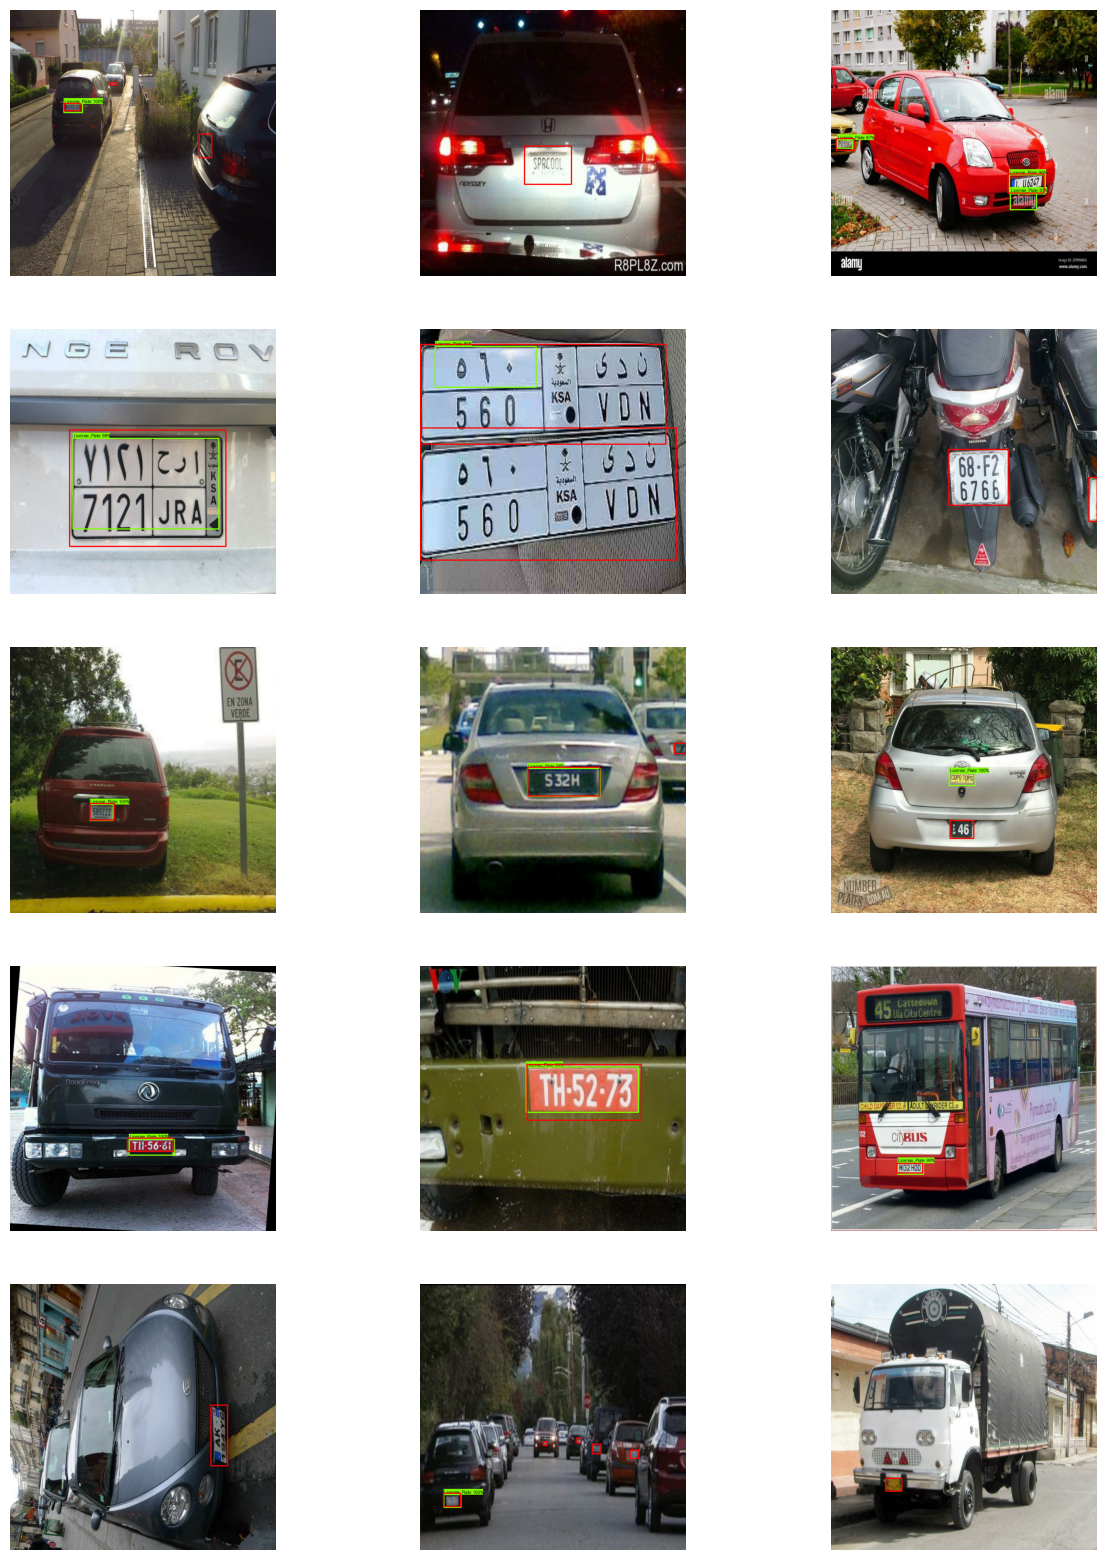

In [20]:
plt.figure(figsize=(15, 20))
label_id_offset = 1
for i in range(total_test_images):
    plt.subplot(5, 3, i+1)
    input_tensor = tf.convert_to_tensor(prepared_test_images[i], dtype=tf.float32)
    _detections = loaded_model.signatures["serving_default"](input_tensor)

    box_img = plot_detections(
      image_np=test_images[i].numpy().astype(np.uint8),
      boxes=_detections['detection_boxes'][0].numpy(),
      classes=_detections['detection_classes'][0].numpy().astype(np.uint32) + label_id_offset,
      scores=_detections['detection_scores'][0].numpy(),
      category_index=category_index, 
      # figsize=(15, 20)
      )
    
    final_img = plot_detections(
    image_np=box_img,
    boxes=test_bboxes[i],
    classes=test_class_ids[i],
    scores=None,
    category_index=category_index, 
    # figsize=(15, 20),
    groundtruth_box_visualization_color='Red',
    use_normalized_coordinates=True
    )

    plt.imshow(final_img)
    plt.axis('off')
plt.show()

## Intersection over union

In [51]:
def intersection_over_union(pred_box, true_box):
    if pred_box.shape == (0,4):
        return np.array([[]])
    ymin_pred, xmin_pred, ymax_pred, xmax_pred = np.split(pred_box, 4, axis=0)
    ymin_true, xmin_true, ymax_true, xmax_true = np.split(true_box, 4, axis=0)

    SMOOTHING_FACTOR = 1e-10

    xmin_overlap = np.maximum(xmin_pred, xmin_true)
    ymin_overlap = np.maximum(ymin_pred, ymin_true)
    xmax_overlap = np.minimum(xmax_pred, xmax_true)
    ymax_overlap = np.minimum(ymax_pred, ymax_true)

    pred_box_area = (xmax_pred - xmin_pred) * (ymax_pred - ymin_pred)
    true_box_area = (xmax_true - xmin_true) * (ymax_true - ymin_true)

    overlap_area = np.maximum((xmax_overlap - xmin_overlap), 0) * np.maximum((ymax_overlap - ymin_overlap), 0)
    union_area = (pred_box_area + true_box_area) - overlap_area

    iou = (overlap_area + SMOOTHING_FACTOR) / (union_area + SMOOTHING_FACTOR)
    return iou    

[[0.35270768 0.2024615  0.38496298 0.2719156 ]]
[]
[[0.61987394 0.67133904 0.6908197  0.8048774 ]
 [0.48862815 0.02409044 0.5191903  0.08252158]
 [0.68684703 0.67495805 0.7514816  0.7725665 ]]
[[0.41477025 0.23670954 0.75575376 0.7858055 ]]
[[0.06898003 0.05688818 0.22265974 0.43725967]]
[]
[[0.59114325 0.30074266 0.6530367  0.38837364]]
[[0.4575876  0.4032278  0.5620165  0.67675364]]
[[0.47398007 0.44510287 0.5203417  0.5428507 ]]
[[0.6547251  0.4479063  0.7156069  0.61734885]]
[[0.38392606 0.39892164 0.5536502  0.8205401 ]]
[[0.7444434  0.2501323  0.78656995 0.34741172]]
[]
[[0.79144967 0.08968201 0.84041536 0.15421988]]
[]


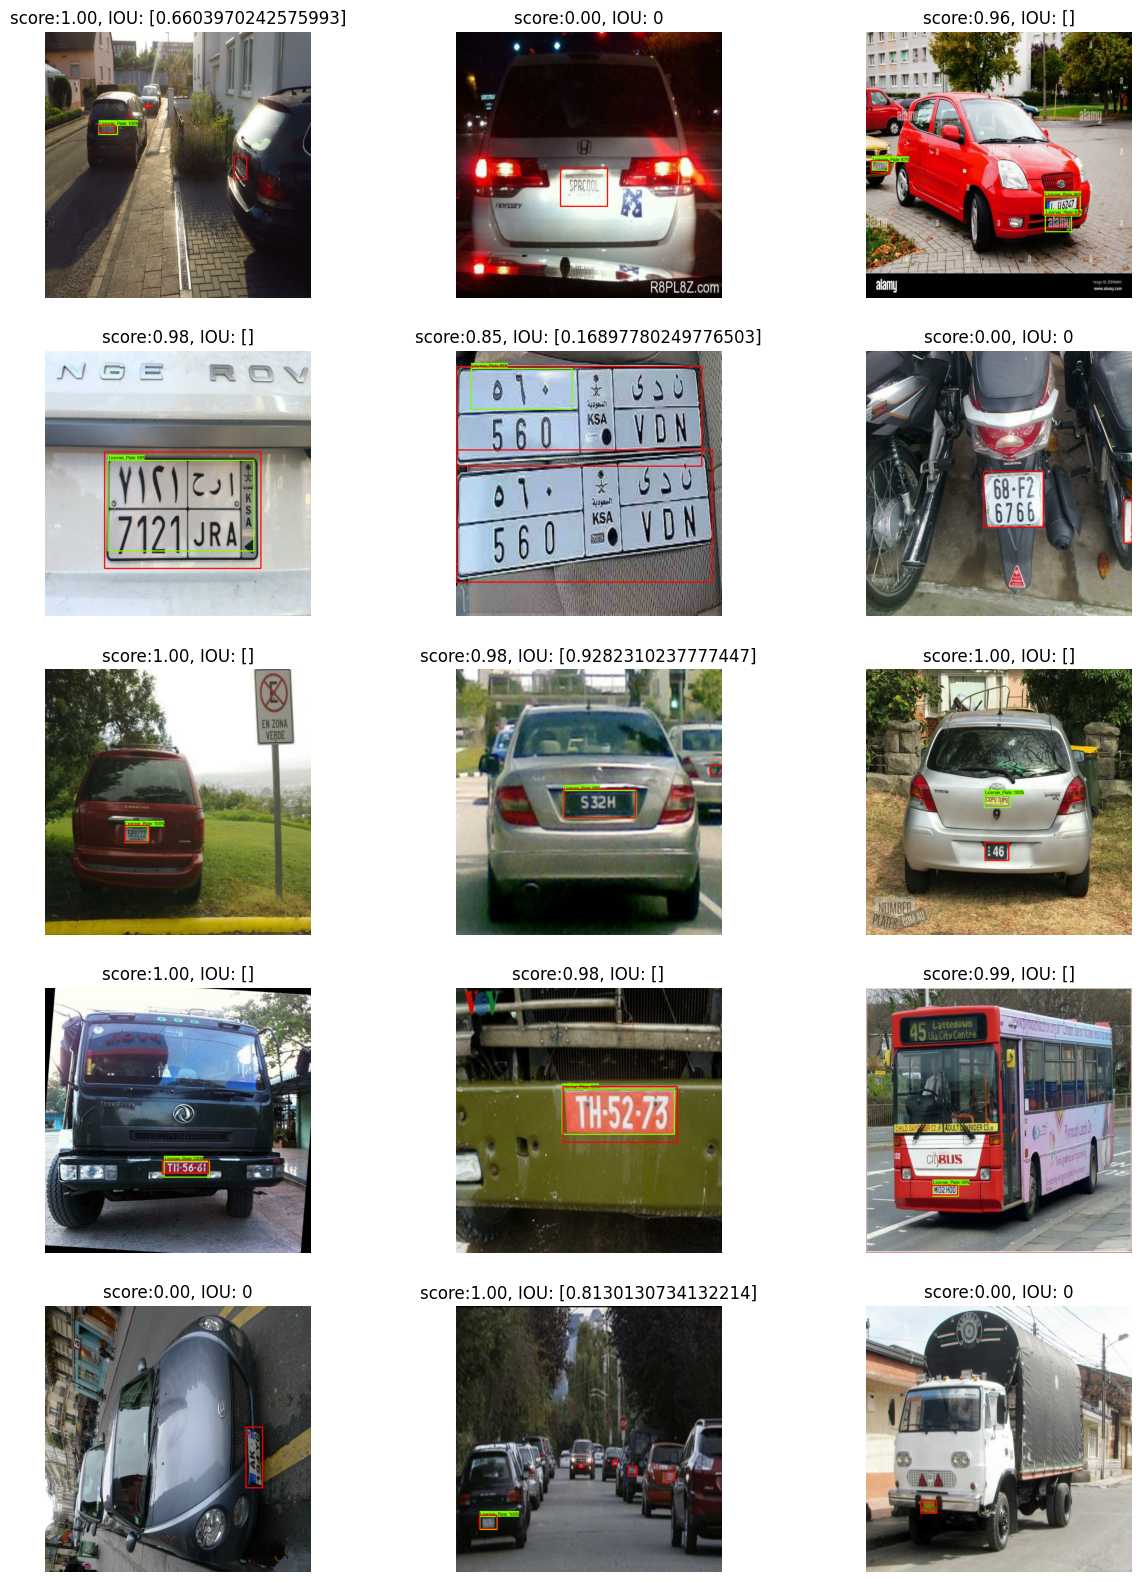

In [56]:
plt.figure(figsize=(15, 20))
label_id_offset = 1

for i in range(total_test_images):
    plt.subplot(5, 3, i+1)
    input_tensor = tf.convert_to_tensor(prepared_test_images[i], dtype=tf.float32)
    _detections = loaded_model.signatures["serving_default"](input_tensor)
    score=_detections['detection_scores'][0].numpy() 
    box_img = plot_detections(
      image_np=test_images[i].numpy().astype(np.uint8),
      boxes=_detections['detection_boxes'][0].numpy(),
      classes=_detections['detection_classes'][0].numpy().astype(np.uint32) + label_id_offset,
      scores=score,
      category_index=category_index, 
      )
    
    final_img = plot_detections(
    image_np=box_img,
    boxes=test_bboxes[i],
    classes=test_class_ids[i],
    scores=None,
    category_index=category_index, 
    groundtruth_box_visualization_color='Red'
    )

    threshold_bboxes = _detections["detection_boxes"][0].numpy()[_detections["detection_scores"][0].numpy() > THRESHOLD_BBOXES]
    print(threshold_bboxes)
    # iou = intersection_over_union(threshold_bboxes, test_bboxes[i])[0] if threshold_bboxes.size > 0 else np.array([])
            # Calculate IoU (handle empty detections)
    iou = 0.0
    if threshold_bboxes.size > 0 and test_bboxes[i].size > 0:
        iou_list = []
        if test_bboxes[i].size >threshold_bboxes.size:
            for gt_box in test_bboxes[i]:
                for pred_box in threshold_bboxes:
                    iou_list.append(intersection_over_union(pred_box, gt_box).item())
            
        iou_list.sort()
        iou = iou_list[-len(threshold_bboxes):]
    else:
        iou=0
    score = score[score>THRESHOLD_BBOXES]
    score = score[0] if score.size > 0 else 0
    
    plt.title(f'score:{score:.2f}, IOU: {iou}')
    plt.imshow(final_img)
    plt.axis('off')
plt.show()

In [ ]:
#---IoU calculation function---
def calculate_iou(test_bboxes, threshold_bboxes, i, intersection_over_union):
    if len(threshold_bboxes) > 0 and len(test_bboxes[i]) > 0:
        # Create a matrix of IoU values
        iou_matrix = np.zeros((len(test_bboxes[i]), len(threshold_bboxes)))
        for gt_idx, gt_box in enumerate(test_bboxes[i]):
            for pred_idx, pred_box in enumerate(threshold_bboxes):
                iou_matrix[gt_idx, pred_idx] = intersection_over_union(pred_box, gt_box).item()

        # Find the best match for each predicted box
        matched_gt_indices = np.argmax(iou_matrix, axis=0)
        iou = iou_matrix[matched_gt_indices, np.arange(len(threshold_bboxes))].tolist()
    else:
        iou = []  # Return an empty list when no boxes are present
    return iou

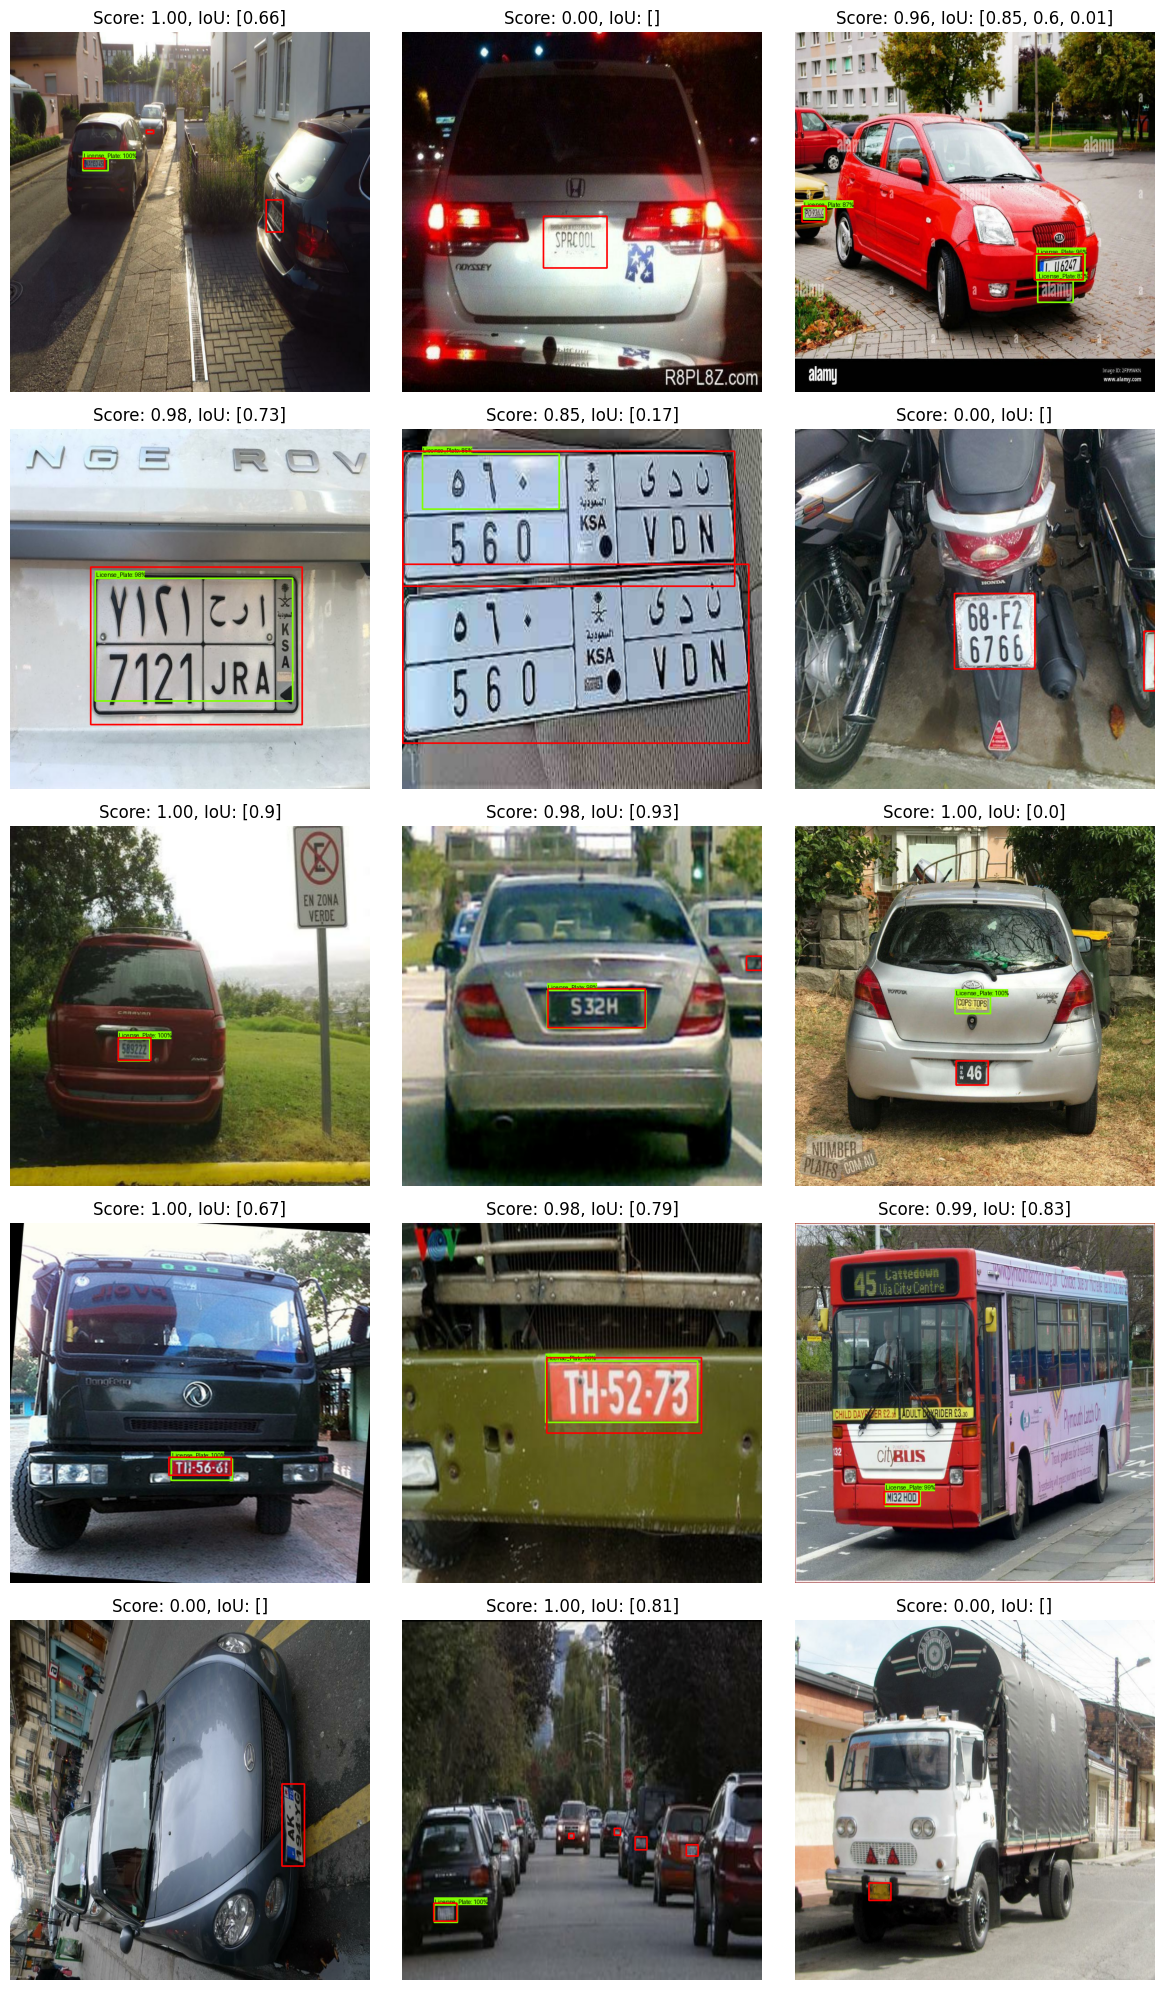

In [79]:
label_id_offset = 1

plt.figure(figsize=(12, 20))

for i in range(total_test_images):
    plt.subplot(5, 3, i + 1)
    input_tensor = tf.convert_to_tensor(prepared_test_images[i], dtype=tf.float32)
    _detections = loaded_model.signatures["serving_default"](input_tensor)
    score = _detections["detection_scores"][0].numpy()
    box_img = plot_detections(
        image_np=test_images[i].numpy().astype(np.uint8),
        boxes=_detections["detection_boxes"][0].numpy(),
        classes=_detections["detection_classes"][0].numpy().astype(np.uint32) + label_id_offset,
        scores=score,
        category_index=category_index,
    )

    final_img = plot_detections(
        image_np=box_img,
        boxes=test_bboxes[i],
        classes=test_class_ids[i],
        scores=None,
        category_index=category_index,
        groundtruth_box_visualization_color="Red",
    )

    threshold_bboxes = _detections["detection_boxes"][0].numpy()[_detections["detection_scores"][0].numpy() > THRESHOLD_BBOXES]
    iou = calculate_iou(test_bboxes, threshold_bboxes, i, intersection_over_union)

    score = score[score > THRESHOLD_BBOXES]
    score = score[0] if score.size > 0 else 0
    _iou= [float(f"{val:.2f}") for val in iou]
    plt.title(f"Score: {score:.2f}, IoU: {_iou}")
    plt.imshow(final_img)
    plt.axis("off")

plt.tight_layout() #prevents overlapping of plots.
plt.savefig("readme-assets/detection_results.png")  # Save the plot to a file